In [1]:
import pandas as pd 
import numpy as np

p = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-16_09-46-32.txt.gz", sep="\t")

In [2]:
p

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,transcripts,both_ends_transcripts,only_5_prime_transcripts,only_3_prime_transcripts,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSMUSG00000025902.13,Sox17,protein_coding,3,exon_skip,NaN,"ENSMUST00000116652.7,ENSMUST00000027035.9","ENSMUST00000191647.1,ENSMUST00000192650.5,ENSM...",ENSMUST00000192913.1,...,0.4698,0.4698,1.0000,68200,32037,GC-AG,GC,AG,1.0,0.0
1,ATSE_0,ENSMUSG00000025902.13,Sox17,protein_coding,3,exon_skip,NaN,"ENSMUST00000192913.1,ENSMUST00000116652.7,ENSM...",NaN,"ENSMUST00000191647.1,ENSMUST00000192650.5,ENSM...",...,1.0000,1.0000,0.9629,938917,975080,GT-AG,GT,AG,1.0,0.0
2,ATSE_0,ENSMUSG00000025902.13,Sox17,protein_coding,3,exon_skip,NaN,"ENSMUST00000195555.1,ENSMUST00000192650.5,ENSM...",NaN,"ENSMUST00000192913.1,ENSMUST00000191939.1",...,0.0371,0.0371,0.5302,975080,68200,GC-AG,GC,AG,1.0,0.0
3,ATSE_1,ENSMUSG00000025902.13,Sox17,protein_coding,2,alternative_3_prime,NaN,ENSMUST00000191647.1,"ENSMUST00000195555.1,ENSMUST00000192650.5,ENSM...",NaN,...,0.7989,0.7989,1.0000,84269,67321,GT-AG,GT,AG,1.0,0.0
4,ATSE_1,ENSMUSG00000025902.13,Sox17,protein_coding,2,alternative_3_prime,NaN,"ENSMUST00000192650.5,ENSMUST00000192913.1,ENSM...","ENSMUST00000191647.1,ENSMUST00000195555.1,ENSM...",NaN,...,0.2011,0.2011,1.0000,84269,16948,GT-AG,GT,AG,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53574,ATSE_17823,ENSMUSG00000027793.6,Ccna1,protein_coding,2,alternative_5_prime,NaN,"ENSMUST00000197238.4,ENSMUST00000198102.4,ENSM...",NaN,NaN,...,0.2669,0.2669,1.0000,10762,2872,GT-AG,GT,AG,-71.0,0.0
53575,ATSE_17824,ENSMUSG00000112110.1,AC158605.1,lincRNA,2,alternative_5_prime,NaN,NaN,NaN,"ENSMUST00000217860.1,ENSMUST00000156803.8",...,0.6335,1.0000,0.6335,6287,9924,GT-AG,GT,AG,NaN,1.0
53576,ATSE_17824,ENSMUSG00000112110.1,AC158605.1,lincRNA,2,alternative_5_prime,NaN,"ENSMUST00000217860.1,ENSMUST00000156803.8",NaN,NaN,...,1.0000,0.3665,1.0000,9924,3637,GT-AG,GT,AG,0.0,1.0
53577,ATSE_17825,ENSMUSG00000091230.1,Gm6970,protein_coding,2,alternative_3_prime,NaN,NaN,NaN,ENSMUST00000169692.1,...,0.4546,0.4546,1.0000,3108,1413,GT-AG,GT,AG,NaN,-24.0


In [3]:
import sys 
import gffutils 

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [4]:
db_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db = gffutils.FeatureDB(db_file, keep_order=True)

In [5]:
# remove both_ends_transcripts it's confusing
p.drop(columns=["transcripts", "both_ends_transcripts", "only_5_prime_transcripts", "only_3_prime_transcripts"], inplace=True)

In [ ]:
import networkx as nx

# Helper to extract donor and acceptor
def extract_sites(junction_id):
    chrom, start, end, strand = junction_id.split("_")
    start, end = int(start), int(end)
    if strand == "+":
        donor, acceptor = start, end
    else:
        donor, acceptor = end, start
    return donor, acceptor

# Function to compute connected components of junctions via shared splice sites
def check_atse_connectivity(df):
    inconsistent_atse_ids = []

    for atse_id, group in df.groupby("event_id"):
        G = nx.Graph()
        junctions = group["junction_id"].unique()

        for j in junctions:
            donor, acceptor = extract_sites(j)
            for other in junctions:
                if j == other:
                    continue
                other_donor, other_acceptor = extract_sites(other)
                if donor == other_donor or acceptor == other_acceptor:
                    G.add_edge(j, other)

        # Add any isolated nodes (single junctions with no overlap)
        for j in junctions:
            G.add_node(j)

        if nx.number_connected_components(G) > 1:
            inconsistent_atse_ids.append(atse_id)

    return pd.DataFrame({"event_id": inconsistent_atse_ids})

# Run the consistency check
inconsistent_df = check_atse_connectivity(p)

In [8]:
# check if "ATSE_7515" is in the inconsistent_df
if "ATSE_7515" in inconsistent_df["event_id"].values:
    print("ATSE_7515 is inconsistent")
else:
    print("ATSE_7515 is consistent")

ATSE_7515 is inconsistent


In [13]:
# filter p to remove ATSEs event_id that are in inconsistent_df
p = p[~p["event_id"].isin(inconsistent_df["event_id"])]

In [17]:
p[["event_id", "splice_motif"]].groupby("event_id")["splice_motif"].value_counts()

event_id   splice_motif
ATSE_0     GC-AG           2
           GT-AG           1
ATSE_1     GT-AG           2
ATSE_10    GT-AG           3
ATSE_100   GT-AG           7
                          ..
ATSE_9995  GT-AG           2
ATSE_9996  GT-AG           3
ATSE_9997  GT-AG           2
ATSE_9998  GT-AG           3
ATSE_9999  GT-AG           3
Name: count, Length: 16453, dtype: int64

In [19]:
atse_event = p.sample(1)["event_id"].values[0]
atse_event = "ATSE_0"
# atse_event = "ATSE_7515"
# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = p[p["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)
splice_junctions

[{'chrom': 'chr1',
  'start': 4493466,
  'end': 4493771,
  'name': 'junction_1',
  'strand': '-',
  'usage_ratio': 0.031810603931817255},
 {'chrom': 'chr1',
  'start': 4492668,
  'end': 4493099,
  'name': 'junction_2',
  'strand': '-',
  'usage_ratio': 0.9322819493663597},
 {'chrom': 'chr1',
  'start': 4492668,
  'end': 4493771,
  'name': 'junction_3',
  'strand': '-',
  'usage_ratio': 0.03590744670182312}]

In [20]:
from typing import List, Set


def extract_unique_transcripts(juncs: pd.DataFrame) -> List[str]:
    """
    Extract unique transcripts from all transcript-related columns in junction DataFrame.
    Handles string lists, NA values, and ensures uniqueness.
    
    Args:
        juncs: DataFrame containing junction data with transcript columns
        
    Returns:
        List of unique transcript IDs
    """
    # Columns to extract transcripts from
    transcript_columns = [
        "both_ends_transcripts", 
        "only_5_prime_transcripts", 
        "only_3_prime_transcripts", 
        "perfect_match_5_prime", 
        "perfect_match_3_prime"
    ]
    
    # Set to store unique transcripts
    all_transcripts: Set[str] = set()
    
    # Process each column
    for column in transcript_columns:
        if column not in juncs.columns:
            print(f"Warning: Column '{column}' not found in DataFrame")
            continue
            
        # Process each row in the column
        for value in juncs[column]:
            # Skip NA/None values
            if pd.isna(value) or value == 'NA' or value is None:
                continue
                
            # Handle string lists (comma-separated values)
            if isinstance(value, str):
                # Skip empty strings
                if value.strip() == '':
                    continue
                    
                # Split by comma and add each transcript to the set
                for transcript in value.split(','):
                    transcript = transcript.strip()
                    if transcript and transcript != 'NA':
                        all_transcripts.add(transcript)
            
            # Handle actual Python lists
            elif isinstance(value, list):
                for transcript in value:
                    if transcript and not pd.isna(transcript) and transcript != 'NA':
                        all_transcripts.add(str(transcript))
    
    # Convert set to sorted list for consistent output
    return sorted(list(all_transcripts))

# Example usage:
unique_transcripts = extract_unique_transcripts(juncs)
print(f"Found {len(unique_transcripts)} unique transcripts")

Found 6 unique transcripts


                     transcript_name transcript_type         transcript_id
ENSMUST00000027035.9       Sox17-201  protein_coding  ENSMUST00000027035.9
ENSMUST00000116652.7       Sox17-202  protein_coding  ENSMUST00000116652.7
ENSMUST00000191647.1       Sox17-203  protein_coding  ENSMUST00000191647.1
ENSMUST00000191939.1       Sox17-204  protein_coding  ENSMUST00000191939.1
ENSMUST00000192650.5       Sox17-206  protein_coding  ENSMUST00000192650.5
ENSMUST00000192913.1       Sox17-207  protein_coding  ENSMUST00000192913.1
Plot saved to test.pdf!


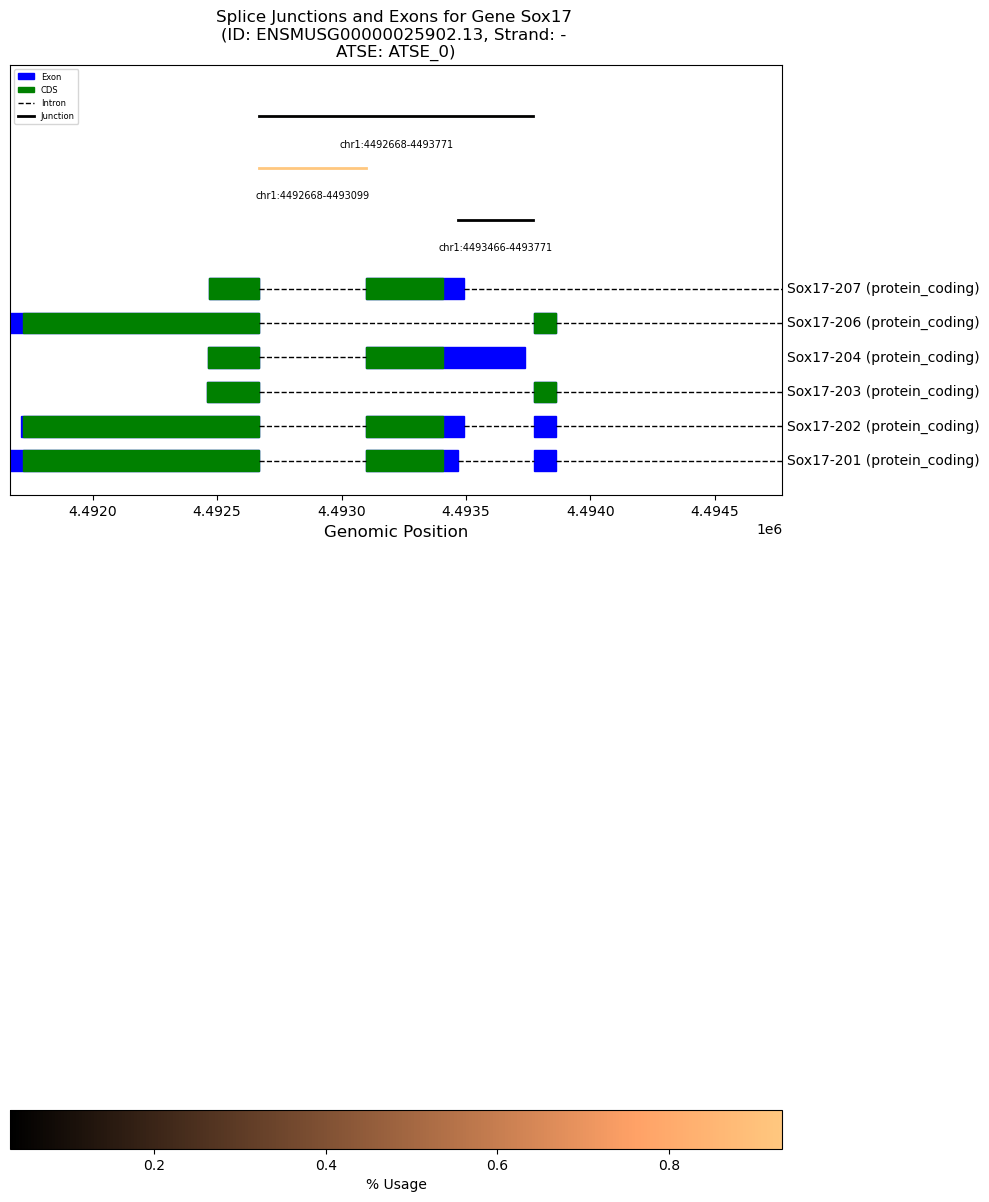

In [21]:
# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=10, trans_height=2, show_usage=True, show_junc_lines=False, filename="test.pdf")

In [22]:
juncs.iloc[1]

event_id                                                            ATSE_0
gene_id                                              ENSMUSG00000025902.13
gene_name                                                            Sox17
gene_types                                                  protein_coding
num_junctions                                                            3
event_type                                                       exon_skip
transcript_types                                            protein_coding
annotation_status                                                     both
perfect_match_5_prime    ENSMUST00000027035.9,ENSMUST00000116652.7,ENSM...
perfect_match_3_prime    ENSMUST00000027035.9,ENSMUST00000192650.5,ENSM...
junction_id                                         chr1_4492668_4493099_-
chrom                                                                 chr1
start                                                              4492668
end                      